## The book sheet

Given that I'm a big reader, my Christmas(/Sinterklaas) wish lists tend to include a generic request for "books". When I heard that my siblings were having to sneak up to my room to check whether I already owned the book they intended to gift me, I decided there must be a better way. I created a spreadsheet to document books I owned and books I still wanted to read, which I share with the family every year. In addition, now that I had it, it became an interesting document with which to reflect on my reading habits.

Before diving into it deeper, I wanted to explain that:
- I have not fully read each book on the list. A few are anthologies of which I've only read a fraction.
- Not each book I have read is on the list. Only those books are on there that I own personally (or have owned in the past), so it misses a lot of my childhood books, books I've read in ebook format, and books I borrowed from someone else.

For the purposes of the analysis, I'm prepared to call it a wash and assume these roughly balance each other out.

#### Most-read author dashboard
The most obvious immediate use was to check for my favourite authors and the editions of their books that I tended to buy, sliced by the language I read them in:

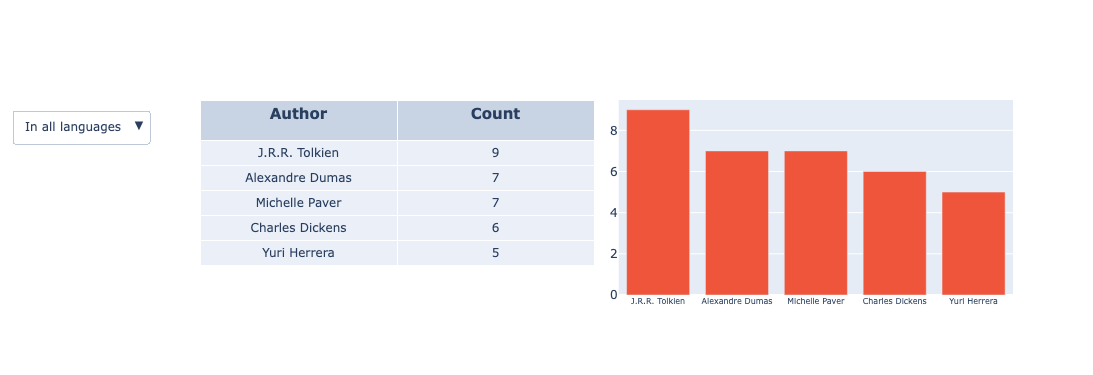

In [58]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import constants
from constants import country_coordinates_JSON

#Read the book sheet in my drive
def read_gsheet(gsheetkey,gsheet_name):
    url=f'https://docs.google.com/spreadsheet/ccc?key={gsheetkey}&output=xlsx'
    book_sheet_df = pd.read_excel(url,sheet_name=gsheet_name)
    return book_sheet_df

#Graph showing top 5 authors/publishers by language
def create_podium_chart(book_sheet_df,Author_or_Publisher):
    #Set up the two subplots: a table and a bar, each occupying half of the screen split vertically
    podium_chart=make_subplots(
    rows=1, cols=2,
    shared_yaxes=True,
    horizontal_spacing=0.03,
    specs=[[{'type':'table'},{'type':'bar'}]]
    )
    
    #Create possible dataframes
    variable_df_All=book_sheet_df.groupby(Author_or_Publisher)[Author_or_Publisher].count().sort_values(ascending=False).head().reset_index(name='Count')
    variable_df_English=book_sheet_df.query("Language=='English'").groupby(Author_or_Publisher)[Author_or_Publisher].count().sort_values(ascending=False).head().reset_index(name='Count')
    variable_df_Nederlands=book_sheet_df.query("Language=='Nederlands'").groupby(Author_or_Publisher)[Author_or_Publisher].count().sort_values(ascending=False).head().reset_index(name='Count')
    variable_df_Español=book_sheet_df.query("Language=='Español'").groupby(Author_or_Publisher)[Author_or_Publisher].count().sort_values(ascending=False).head().reset_index(name='Count')
    
    #Set up four tables, only one visible by default
    podium_chart.add_trace(
        go.Table(
            name=Author_or_Publisher+'_All',
            header_values=[Author_or_Publisher,'Count'],
            cells_values=[variable_df_All[k].tolist() for k in variable_df_All],
            visible=True
        ),
        row=1,col=1,
        )
    podium_chart.add_trace(
        go.Table(
            name=Author_or_Publisher+'_English',
            header_values=[Author_or_Publisher,'Count'],
            cells_values=[variable_df_English[k].tolist() for k in variable_df_English],
            visible=False
        ),
        row=1,col=1
        )
    podium_chart.add_trace(
        go.Table(
            name=Author_or_Publisher+'_Nederlands',
            header_values=[Author_or_Publisher,'Count'],
            cells_values=[variable_df_Nederlands[k].tolist() for k in variable_df_Nederlands],
            visible=False
        ),
        row=1,col=1
        )
    podium_chart.add_trace(
        go.Table(
            name=Author_or_Publisher+'_Español',
            header_values=[Author_or_Publisher,'Count'],
            cells_values=[variable_df_Español[k].tolist() for k in variable_df_Español],
            visible=False
        ),
        row=1,col=1
        )
    podium_chart.update_traces(
        header_height=40,
        header_font_size=15,
        header_font_weight=999,
        cells_height=25,
        cells_font_size=12
    )    
    
    #Set up four bars, only one visible by default
    podium_chart.add_trace(
        go.Bar(
            name=Author_or_Publisher+'_All',
            x=variable_df_All[Author_or_Publisher],
            y=variable_df_All['Count'],
            visible=True
        ),
        row=1,col=2
    )
    podium_chart.add_trace(
        go.Bar(
            name=Author_or_Publisher+'_English',
            x=variable_df_English[Author_or_Publisher],
            y=variable_df_English['Count'],
            visible=False
        ),
        row=1,col=2
    )
    podium_chart.add_trace(
        go.Bar(
            name=Author_or_Publisher+'_Nederlands',
            x=variable_df_Nederlands[Author_or_Publisher],
            y=variable_df_Nederlands['Count'],
            visible=False
        ),
        row=1,col=2
    ) 
    podium_chart.add_trace(
        go.Bar(
            name=Author_or_Publisher+'_Español',
            x=variable_df_Español[Author_or_Publisher],
            y=variable_df_Español['Count'],
            visible=False
        ),
        row=1,col=2
    )
    podium_chart.update_xaxes(
        tickfont_size=8
    )

    #Add a button that modify which of the tables/bar charts you can see
    podium_chart.update_layout(
        updatemenus=[
        {'buttons':[{
                    'label': "In all languages",
                    'method': "update",
                    'args':[
                        {'visible': [True,False,False,False,True,False,False,False]}]},
                    {
                    'label': "In English",
                    'method': "update",
                    'args':[
                        {'visible': [False,True,False,False,False,True,False,False]}]},
                    {
                    'label': "In Nederlands",
                    'method': "update",
                    'args':[
                        {'visible': [False,False,True,False,False,False,True,False]}]},
                    {
                    'label': "En Español",
                    'method': "update",
                    'args':[
                        {'visible': [False,False,False,True,False,False,False,True]}]},
            ],
            'type':'dropdown',
            'direction':'down',
            'pad': {"r": 10, "t": 10},
            'showactive': True}
    ])
    return podium_chart

#Actually run the functions that were defined above
book_sheet_df=read_gsheet(
    gsheetkey=gsheetkey,
    gsheet_name=gsheet_name
)
podium_chart=create_podium_chart(
    book_sheet_df=book_sheet_df,
    Author_or_Publisher='Author'
)
podium_chart.show()

<br> 
<br>

#### Most-read publisher dashboard 
... and the same can be done for publishers by changing the input to the function:

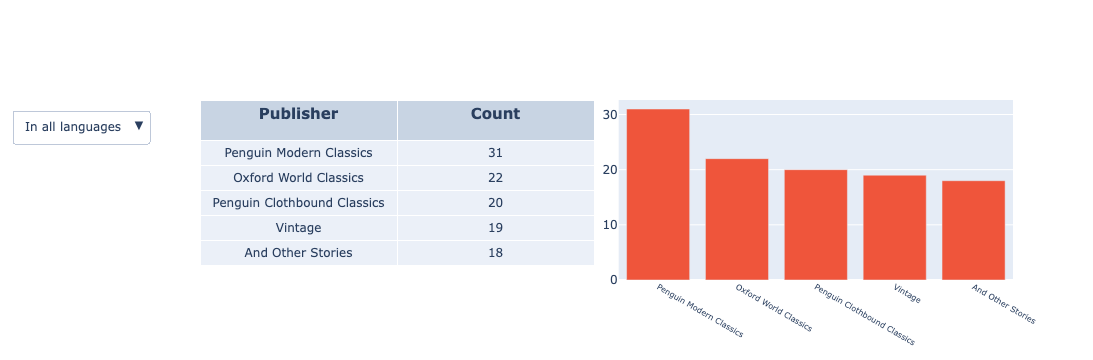

In [57]:
#Run the functions with a different input
podium_chart=create_podium_chart(
    book_sheet_df=book_sheet_df,
    Author_or_Publisher='Publisher'
)
podium_chart.show()


Ideally, I would have liked to have one chart with a second dropdown menu to select between 'Author' or 'Publisher'. Unfortunately, it seems plotly doesn't have buttons that support the requirement.
<br>
<br>

#### Language splits
From looking at the above dashboards, it becomes fairly obvious that I do most of my reading in English. Here is a closer look at which languages I read in:

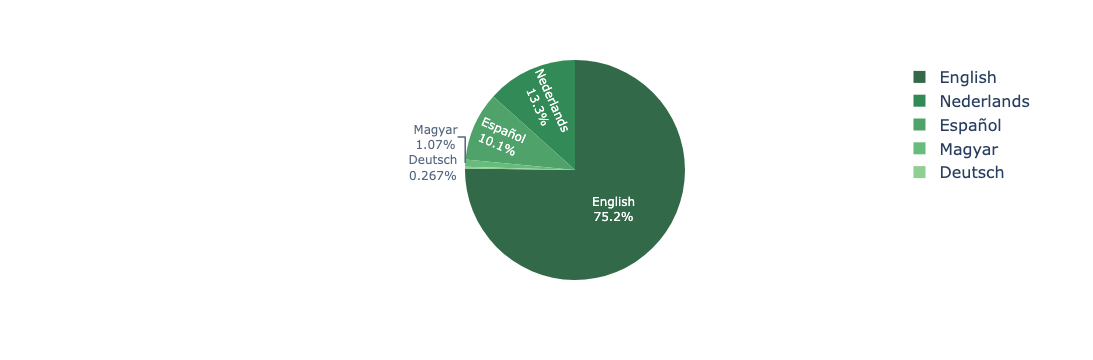

In [59]:
#Create a basic chart that shows what languages I primarily read in
def create_language_distribution_pie(book_sheet_df):
    language_counts_series=book_sheet_df.groupby('Language')['Language'].count().reset_index(name='Count')
    language_distribution_pie=px.pie(
        data_frame=language_counts_series,
        values='Count',
        names='Language',
        color_discrete_sequence=px.colors.sequential.Greens_r
        )
    language_distribution_pie.update_traces(
        opacity=0.8,
        textinfo='label+percent'
        )
    language_distribution_pie.update_layout(
        legend_font={
            'size':16
        })
    return language_distribution_pie

#Run the function
language_distribution_pie=create_language_distribution_pie(
    book_sheet_df=book_sheet_df
)
language_distribution_pie.show()

English dominates my reading. Most works that I have to read in translation, I will read in English. Largely, this is for practical reasons:
- I live in England, so books in English are easier to get
- Books in English tend to be a lot cheaper than books in Dutch
- I don't read super fast in Spanish

Given the low number of books I read in Hungarian or German, I excluded them from the author and publisher slices. They would provide pretty disappointing data. Maybe I will try to include them once my Hungarian improves and I read a more interesting selection of books in the language.
<br>
<br>

#### Location analysis
At this point, I reached the limit of the information that I originally captured in my book sheet. However, I realised I could do cooler analyses if I added other datapoints to the sheet. Perhaps my favourite one that I added is author nationality:

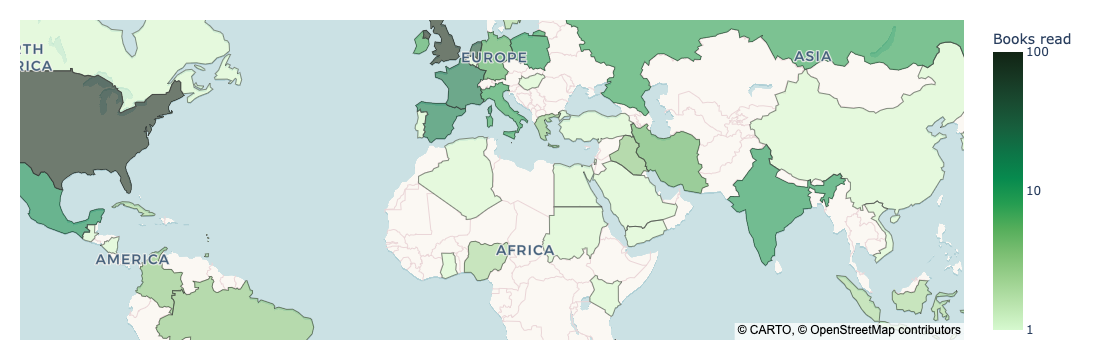

In [55]:
import json
import numpy as np

#First, we need to actually count author nationalities. Some authors have dual nationalities and need to be double-counted.
#To make this happen, I've documented double nationalities split by a ; symbol, e.g. "GBR; USA".
#The below function splits the multiple nationalities into different columns, then collapses them back into one series and counts them.
def count_author_nationalities(book_sheet_df):
    author_nationality_df=book_sheet_df['Author nationality'].str.split(pat='; ',expand=True)
    author_nationality_series=author_nationality_df.stack()
    author_nationality_count_df=author_nationality_series.value_counts().to_frame().reset_index(names='index')
    return author_nationality_count_df

#In addition, in order to make a nice-looking map, I needed to load in coordinates of various countries
def read_geoJSON(JSON_location):
    with open(JSON_location, 'r') as f:
        country_coordinates = json.load(f)
    return country_coordinates

#Finally, I could create a big world map
def create_author_nationality_counts_map(author_nationality_count_df,country_coordinates):
    author_nationality_counts_map= px.choropleth_map(data_frame=author_nationality_count_df,
                            locations='index',
                            geojson=country_coordinates,
                            #Note that I've coloured the tiles on the map logarithmically, as that better matches the spread in the data
                            color=np.log10(author_nationality_count_df['count']),
                            hover_data={'count'},
                            color_continuous_scale='algae',
                            range_color=(0,2),
                            opacity=0.6,
                            zoom=1.5,
                            center={"lat":28.038799,"lon":9.579170},
                            map_style='basic'
                          )
    author_nationality_counts_map.update_layout(
                            margin={"r":20,"t":20,"l":20,"b":20},
                            coloraxis_colorbar={
                            'title': dict(text="Books read"),
                            'tickvals': [0,1,2],
                            'ticktext': ['1', "10", "100"]},
                            hoveranywhere=True
                            )
    return author_nationality_counts_map

author_nationality_count_df=count_author_nationalities(
    book_sheet_df=book_sheet_df
)
country_coordinates=read_geoJSON(
    JSON_location=country_coordinates_JSON
)
author_nationality_counts_map=create_author_nationality_counts_map(
    author_nationality_count_df=author_nationality_count_df,
    country_coordinates=country_coordinates
)

author_nationality_counts_map.show()

The map shows I have some clear blindspots in Eastern Europe, Central Asia, South-East Asia, and non-Anglophone Africa.

An important nuance to add is that this is based on author nationalities, not the topic they write about. This cuts both ways:
 - I actually read multiple books about Haiti, but these were written by Cuban and Trinidadian authors. As a result, Haiti remains uncoloured.
 - Although I've read a number of books from authors with Polish nationalities, none of them are *about* or even *set in* Poland. Instead, the Witcher series is fantasy and the two books by Ryszard Kapuściński I read were about Ethiopia and Iran, respectively.

Nonetheless, it's a useful tool to reflect on whose voices I listen to by default and which ones I should work harder to find.
<br>
<br>

#### Timeline
Following the author nationality analysis, I thought I would do something similar in the dimension of time, instead of space. I decided to use the original publication date of books I read, since that says more about when it was written then the publication date of the specific edition I owned:

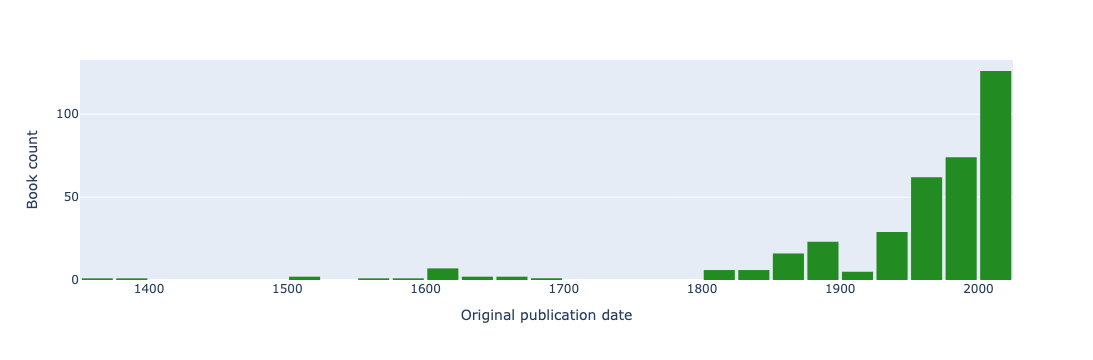

In [64]:
#Create original publication date histogram function
def create_original_publication_date_histogram(book_sheet_df):
    original_publication_date_fig=px.histogram(
        data_frame=book_sheet_df['Original publication date'],
        color_discrete_sequence=['forestgreen'])
    original_publication_date_fig.update_traces(
        hovertemplate=None,
        xbins={
        #I decided to start the histogram in the year 1300, since the data becomes too intermittent after that date
        # for me to present it in an interesting way
        'start':1300,
        'end':2025,
        'size':25})
    original_publication_date_fig.update_layout(
        showlegend=False,
        xaxis_title='Original publication date',
        yaxis_title='Book count',
        bargap=0.1,
        hovermode='x',
        hoverlabel={
            'bgcolor':'aliceblue',
            'font_size':16
        })
    return original_publication_date_fig

#Run the function
original_publication_date_fig=create_original_publication_date_histogram(
    book_sheet_df=book_sheet_df
)
original_publication_date_fig.show()

This roughly presents the image I expected from it: the further in the past something was published, the less likely I will have read it. Although it's starker than I thought, I also expected the gap in the 18th century, since I often struggle to think of books published between the early modern and industrial ages.

The 1900-1924 dip surprises me a little, but I may have avoided it subconsciously because the "Lost Generation"-like pointlessness always struck me as a little depressing.

Slight side note that I finagled with the data of this category a lot more than with that of the others. This is because defining the original publication date can cause some doubts: if my collection of classical theatre (ranging from 200BC to 200AD) was first bundled in this specific configuration in 1975, what date do I say it originates from? I have tended to stick to the earliest date in the range in cases where all contents in the bundle were published relatively close together or an exact publication date for a specific text is difficult to determine. If the range is too wide to reasonably use this approach, I admitted defeat and simply went with when the bundle was originaly published in this configuration.
<br>
<br>

#### Book stacking exercise
This left me with only one (natural) question: how tall would my book tower be if I managed to perfectly balance them all on top of each other?

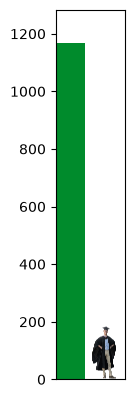

In [81]:
#Unfortunately, plotly didn't support images in graphs, so I had to diversify
import imageio as iio
import matplotlib.pyplot as plt

from constants import avg_page_thickness_cm,my_height_cm

#Create and read the data that will need to go into the chart
def create_book_pile_data(book_sheet_df):
    total_page_count=sum(book_sheet_df['Page count'])
    book_height_if_stacked=total_page_count*avg_page_thickness_cm
    book_pile_y_series=[book_height_if_stacked,my_height_cm]

    #Read in images
    book_stack_colour=iio.v3.imread('/Users/severijnhagemeijer/Documents/Coding/Book sheet/Green.png')
    me_img = iio.v3.imread('/Users/severijnhagemeijer/Documents/Coding/Book sheet/Severijn_figuur.png')
    return book_pile_y_series, book_stack_colour,me_img

#Define the function, based on nebulous image sizes
def create_book_pile_chart(y_series_data, images, spacing=20):
    for i, (height, img) in enumerate(zip(y_series_data, images)):
        width = 100
        left = width*i + spacing*i
        right = left + width
        plt.imshow(img, extent=[left, right, 0, height])
        plt.xlim(0, right*1.1)
        plt.ylim(0, max(y_series_data)*1.1)
        plt.tick_params(
            axis='x',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            bottom=False,      # ticks along the bottom edge are off
            top=False,         # ticks along the top edge are off
            labelbottom=False) # labels along the bottom edge are off

#Run the functions
book_pile_y_series,book_stack_colour,me_img=create_book_pile_data(
    book_sheet_df=book_sheet_df
)
book_pile_chart=create_book_pile_chart(
    y_series_data=book_pile_y_series,
    images=[book_stack_colour,me_img]
)
plt.show()

Although for some reason it will not allow me to add y-labels or a title to the chart, I can report that the book stack would in fact be more than six times my height. I'm excited to check back in to see it grow further!